In [1]:
# =============================================================================
# CÉLULA 1: INSTALAÇÃO DE BIBLIOTECAS
# =============================================================================
# ⏳ Espere essa célula terminar completamente antes de rodar a próxima!
# Quando aparecer "✅ Instalação concluída!", pode ir para a Célula 2.

!pip install pandas scikit-learn joblib yake sentence-transformers matplotlib seaborn numpy -q

print("✅ Instalação concluída!")
print("🔄 Agora vá para a Célula 2 (Imports)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 18.0 MB/s eta 0:00:00
✅ Instalação concluída!
🔄 Agora vá para a Célula 2 (Imports)


In [2]:
# =============================================================================
# CÉLULA 2: IMPORTS
# =============================================================================
import os
import re
import json
import joblib
import warnings
import numpy as np
import pandas as pd
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# YAKE pode dar erro em algumas versões do Colab, então usamos try/except
try:
    import yake
    YAKE_DISPONIVEL = True
    print("✅ YAKE importado com sucesso!")
except ImportError:
    YAKE_DISPONIVEL = False
    print("⚠️  YAKE não disponível. Usaremos TF-IDF para keywords como fallback.")

from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")
print("✅ Todas as bibliotecas carregadas!")

✅ YAKE importado com sucesso!
✅ Todas as bibliotecas carregadas!


In [3]:
# =============================================================================
# CÉLULA 3: CARREGAR O DATASET
# =============================================================================
# Se você fez upload manual do CSV, coloque o nome exato do arquivo aqui:
NOME_ARQUIVO = "techtagger_dataset_expanded.csv"  # <-- Mude se o nome for diferente

# Verifica se existe, senão tenta achar qualquer CSV na pasta
import os
import glob
import pandas as pd # Adicionado para resolver o NameError
csv_files = glob.glob('*.csv')

if not os.path.exists(NOME_ARQUIVO) and csv_files:
    NOME_ARQUIVO = csv_files[0]
    print(f"📁 Usando arquivo encontrado: {NOME_ARQUIVO}")
elif not os.path.exists(NOME_ARQUIVO):
    print("❌ CSV não encontrado. Faça upload do arquivo primeiro!")
    print("   Clique no ícone 📁 à esquerda → Upload")
    raise FileNotFoundError("CSV não encontrado")

df = pd.read_csv(NOME_ARQUIVO)

print(f"✅ Dataset carregado: {len(df)} linhas")
print(f"📊 Colunas: {list(df.columns)}")

# Se não tiver a coluna 'text', cria a partir de title + description
if "text" not in df.columns:
    print("📝 Criando coluna 'text' a partir de title + description...")
    df["text"] = df["title"].fillna("") + ". " + df["description"].fillna("")

# Garante que temos as colunas necessárias
if "category" not in df.columns:
    # Tenta achar uma coluna similar
    possiveis = [c for c in df.columns if any(x in c.lower() for x in ["cat", "label", "class", "tag"])]
    if possiveis:
        df = df.rename(columns={possiveis[0]: "category"})
        print(f"🔄 Coluna '{possiveis[0]}' renomeada para 'category'")
    else:
        raise ValueError("Coluna 'category' não encontrada no CSV!")




print(f"\n📊 Distribuição por categoria:")
print(df["category"].value_counts())

✅ Dataset carregado: 1520 linhas
📊 Colunas: ['title', 'text', 'category']

📊 Distribuição por categoria:
category
Cloud               191
Frontend            190
Backend             190
Data Science        190
Databases           190
Mobile              190
DevOps              190
Data Engineering    189
Name: count, dtype: int64


In [5]:
import re

# ============================================================
# Pré-processamento V4 - Phrase Binding (Junção de Termos)
# ============================================================

tech_replacements = {
    "spring boot": "springboot",
    "react native": "reactnative",
    "machine learning": "machinelearning",
    "data science": "datascience",
    "data engineering": "dataengineering",
    "github actions": "githubactions",
    "object storage": "objectstorage",
    "autonomous database": "autonomousdatabase",
    "kubernetes engine": "kubernetesengine",
    "container instances": "containerinstances",
    "google cloud": "gcp",
    "amazon web services": "aws",
    "oracle cloud": "oci",
    "web components": "webcomponents",
    "server components": "servercomponents",
    "clean architecture": "cleanarchitecture",
    "micro services": "microservices",
    "microservices": "microservices",
    "deep learning": "deeplearning",
    "data lakes": "datalakes",
    "data lake": "datalake",
    "data warehouses": "datawarehouses",
    "data warehouse": "datawarehouse",
    "ci/cd": "cicd",
    "ci / cd": "cicd"
}

def clean_text_v4(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)

    # Padroniza termos compostos cruciais antes de limpar a pontuação
    for target, replacement in tech_replacements.items():
        text = text.replace(target, replacement)

    # Preserva termos técnicos com caracteres especiais
    text = text.replace('c#', 'csharp').replace('.net', 'dotnet')

    # Remove pontuações mantendo letras e números
    text = re.sub(r'[^a-z0-9áéíóúâêîôûãõç\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    tokens_clean = []
    for t in tokens:
        # Ensure stop_words is defined. Assuming it's from a previous import or global scope.
        if 'stop_words' in globals() and t not in stop_words: # Usa a lista padrão de stopwords (PT+EN)
            if len(t) >= 3 or t in ['go', 'js', 'ts', 'db', 'r']:
                tokens_clean.append(t)
        elif 'stop_words' not in globals(): # Fallback if stop_words is not found
            if len(t) >= 3 or t in ['go', 'js', 'ts', 'db', 'r']:
                tokens_clean.append(t)

    return " ".join(tokens_clean)

# Aplica a nova limpeza
df["content_clean"] = df["text"].apply(clean_text_v4)

In [6]:
# ============================================================
# Treinamento de Elite - Ensemble (Voting Classifier)
# ============================================================
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV

X = df["content_clean"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y # Reduzimos o teste para 20% para focar no treino
)

# Definimos os modelos do nosso comitê
clf_svm = CalibratedClassifierCV(
    LinearSVC(class_weight="balanced", random_state=42, max_iter=5000),
    cv=3
)
clf_lr = LogisticRegression(
    class_weight="balanced", random_state=42, max_iter=3000
)

# Criamos o Ensemble com votação suave (soft voting)
ensemble = VotingClassifier(
    estimators=[('svm', clf_svm), ('lr', clf_lr)],
    voting='soft',
    weights=[1.2, 0.8] # Damos um peso maior para o SVM que é mais forte
)

final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        sublinear_tf=True,
        strip_accents='unicode'
    )),
    ("clf", ensemble)
])

# Parametrização cirúrgica do Grid Search
param_grid = {
    "tfidf__max_features": [8000, 10000, 12000],
    "tfidf__ngram_range": [(1, 2)], # unigramas e bigramas limpos
    "tfidf__min_df": [1, 2],
    "clf__svm__estimator__C": [0.5, 1.0, 1.5]
}

grid = GridSearchCV(
    final_pipeline,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train, y_train)

pipeline = grid.best_estimator_
y_pred = pipeline.predict(X_test)

print("\n" + "=" * 60)
print("🚀 MÉTRICAS DO ENSEMBLE DE ELITE")
print("=" * 60)
print(f"Melhores parâmetros: {grid.best_params_}")
print(f"Acurácia final no Teste: {accuracy_score(y_test, y_pred):.2%}")
print(f"F1 Macro no Teste: {f1_score(y_test, y_pred, average='macro'):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


🚀 MÉTRICAS DO ENSEMBLE DE ELITE
Melhores parâmetros: {'clf__svm__estimator__C': 1.0, 'tfidf__max_features': 8000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
Acurácia final no Teste: 94.74%
F1 Macro no Teste: 94.69%

Classification Report:
                  precision    recall  f1-score   support

         Backend       0.95      0.95      0.95        38
           Cloud       0.97      0.97      0.97        38
Data Engineering       0.97      0.84      0.90        38
    Data Science       0.93      1.00      0.96        38
       Databases       0.90      0.97      0.94        38
          DevOps       0.94      0.89      0.92        38
        Frontend       0.95      0.97      0.96        38
          Mobile       0.97      0.97      0.97        38

        accuracy                           0.95       304
       macro avg       0.95      0.95      0.95       304
    weighted avg       0.95      0.95      0.95       304



In [7]:
# =============================================================================
# CÉLULA 5: SPLIT DOS DADOS
# =============================================================================
import numpy as np

X = df["content_clean"].values
y = df["category"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # mantém proporção das categorias
)

print(f"📊 Treino: {len(X_train)} amostras")
print(f"📊 Teste:  {len(X_test)} amostras")
print(f"🏷️  Categorias: {len(np.unique(y))}")

📊 Treino: 1216 amostras
📊 Teste:  304 amostras
🏷️  Categorias: 8


In [9]:
import nltk
from nltk.stem import RSLPStemmer, SnowballStemmer
import re

# Baixa os recursos do NLTK se ainda não foram baixados
nltk.download('rslp', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Stemmers para PT e EN
stemmer_pt = RSLPStemmer()
stemmer_en = SnowballStemmer('english')

# Stopwords customizadas do domínio técnico (palavras que não ajudam a classificar)
custom_stopwords = {
    'content', 'article', 'tutorial', 'learn', 'using', 'with', 'how',
    'this', 'that', 'these', 'those', 'from', 'into', 'about',
    'conteúdo', 'artigo', 'tutorial', 'aprender', 'usando', 'como',
    'este', 'essa', 'esse', 'isso', 'aquele', 'sobre', 'para',
    'also', 'well', 'just', 'like', 'make', 'made', 'new', 'one',
    'também', 'bem', 'apenas', 'como', 'fazer', 'feito', 'novo', 'um', 'uma'
}

# Combina stopwords de PT e EN e as customizadas
stop_words = set(stopwords.words('portuguese') + stopwords.words('english'))
stop_words_all = stop_words.union(custom_stopwords)

def clean_text_v2(text: str) -> str:
    """Limpeza melhorada com stemming."""
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-ZáéíóúàèìòùâêîôûãõçÁÉÍÓÚÀÈÌÒÙÂÊÎÔÛÃÕÇ\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()

    # Remove stopwords e tokens curtos
    tokens = [t for t in tokens if t not in stop_words_all and len(t) > 2]

    # Stemming simples (aplica nos dois stemmers e pega o menor)
    stemmed = []
    for t in tokens:
        try:
            s_pt = stemmer_pt.stem(t)
            s_en = stemmer_en.stem(t)
            stemmed.append(s_pt if len(s_pt) < len(s_en) else s_en)
        except:
            stemmed.append(t)

    return " ".join(stemmed)

In [10]:
# ============================================================
# Treinamento com SVM Calibrado e Grid Search Otimizado
# ============================================================
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV

X = df["content_clean"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.22, random_state=42, stratify=y
)

# Pipeline robusto
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        sublinear_tf=True,  # aplica escala logarítmica (muito importante para texto)
        strip_accents='unicode'
    )),
    ("clf", CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", random_state=42, max_iter=3000),
        cv=3
    ))
])

# Parâmetros focados
param_grid = {
    "tfidf__max_features": [4000, 6000, 8000],
    "tfidf__ngram_range": [(1, 2)], # Bigramas capturam contexto (ex: "spring boot") de forma limpa
    "tfidf__min_df": [1, 2],
    "clf__estimator__C": [0.1, 0.5, 1.0]
}

grid = GridSearchCV(
    final_pipeline,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train, y_train)

# Avaliação final
pipeline = grid.best_estimator_
y_pred = pipeline.predict(X_test)

print("\n" + "=" * 60)
print("🎯 NOVAS MÉTRICAS DO MODELO")
print("=" * 60)
print(f"Melhores parâmetros: {grid.best_params_}")
print(f"Nova Acurácia no Teste: {accuracy_score(y_test, y_pred):.3f}")
print(f"Novo F1 Macro no Teste: {f1_score(y_test, y_pred, average='macro'):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


🎯 NOVAS MÉTRICAS DO MODELO
Melhores parâmetros: {'clf__estimator__C': 1.0, 'tfidf__max_features': 4000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
Nova Acurácia no Teste: 0.958
Novo F1 Macro no Teste: 0.957

Classification Report:
                  precision    recall  f1-score   support

         Backend       0.98      0.95      0.96        42
           Cloud       0.98      1.00      0.99        42
Data Engineering       0.97      0.85      0.91        41
    Data Science       0.93      1.00      0.97        42
       Databases       0.93      0.98      0.95        42
          DevOps       0.95      0.90      0.93        42
        Frontend       0.95      1.00      0.98        42
          Mobile       0.98      0.98      0.98        42

        accuracy                           0.96       335
       macro avg       0.96      0.96      0.96       335
    weighted avg       0.96      0.96      0.96       335



Fitting 5 folds for each of 18 candidates, totalling 90 fits

RESULTADO DO GRID SEARCH
Melhores parâmetros: {'clf__C': 2.0, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 3)}
Melhor F1 (CV):      0.960

Accuracy no teste: 0.955
F1 Weighted teste: 0.955
F1 Macro teste:    0.955

Classification Report:
                  precision    recall  f1-score   support

         Backend       0.95      0.95      0.95        42
           Cloud       0.98      1.00      0.99        42
Data Engineering       0.97      0.85      0.91        41
    Data Science       0.93      1.00      0.97        42
       Databases       0.91      0.98      0.94        42
          DevOps       0.95      0.90      0.93        42
        Frontend       0.95      0.98      0.96        42
          Mobile       1.00      0.98      0.99        42

        accuracy                           0.96       335
       macro avg       0.96      0.95      0.95       335
    weighted avg       0.96      0.96      0.95   

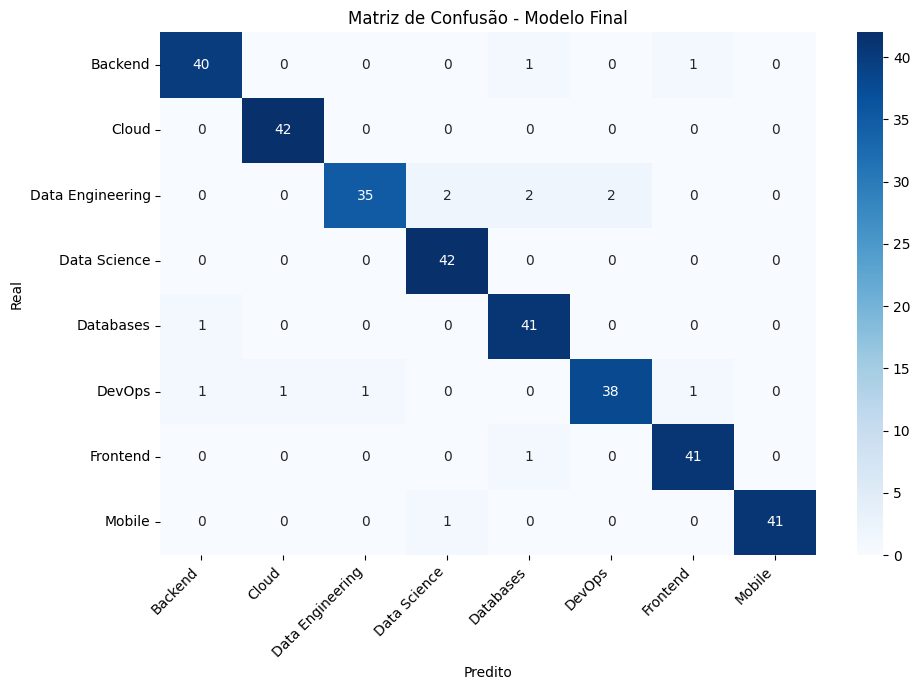

In [11]:
# ============================================================
# Pipeline Final com Grid Search
# ============================================================
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Pipeline com o melhor modelo (vamos usar SVM Linear que geralmente vence)
# Se o seu melhor for outro, troque aqui
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=8000,
        ngram_range=(1, 3),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

# Grid Search para achar os melhores hiperparâmetros
param_grid = {
    "tfidf__max_features": [5000, 8000, 10000],
    "tfidf__ngram_range": [(1, 2), (1, 3)],
    "clf__C": [0.5, 1.0, 2.0],
}

grid = GridSearchCV(
    final_pipeline,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\n" + "=" * 60)
print("RESULTADO DO GRID SEARCH")
print("=" * 60)
print(f"Melhores parâmetros: {grid.best_params_}")
print(f"Melhor F1 (CV):      {grid.best_score_:.3f}")

# Avaliação final no teste
y_pred = grid.best_estimator_.predict(X_test)
print(f"\nAccuracy no teste: {accuracy_score(y_test, y_pred):.3f}")
print(f"F1 Weighted teste: {f1_score(y_test, y_pred, average='weighted'):.3f}")
print(f"F1 Macro teste:    {f1_score(y_test, y_pred, average='macro'):.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Matriz de confusão
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred, labels=grid.best_estimator_.classes_)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=grid.best_estimator_.classes_,
            yticklabels=grid.best_estimator_.classes_)
plt.title("Matriz de Confusão - Modelo Final")
plt.ylabel("Real")
plt.xlabel("Predito")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Guarda o melhor pipeline para serializar
pipeline = grid.best_estimator_

In [12]:
# =============================================================================
# CÉLULA 9: GERAR EMBEDDINGS (demora 1-2 minutos)
# =============================================================================
from sentence_transformers import SentenceTransformer

print("🧠 Carregando modelo de embeddings...")
model_emb = SentenceTransformer("all-MiniLM-L6-v2")

print("🧠 Gerando embeddings para todos os artigos...")
embeddings = model_emb.encode(
    df["content_clean"].tolist(),
    show_progress_bar=True,
    batch_size=32  # menor batch para não estourar memória
)

print(f"\n✅ Embeddings gerados! Shape: {embeddings.shape}")

🧠 Carregando modelo de embeddings...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

🧠 Gerando embeddings para todos os artigos...


Batches:   0%|          | 0/48 [00:00<?, ?it/s]


✅ Embeddings gerados! Shape: (1520, 384)


In [13]:
import numpy as np # Import numpy for argsort, if not already imported globally

# =============================================================================
# CÉLULA 10: KEYWORDS (YAKE ou Fallback)
# =============================================================================
if YAKE_DISPONIVEL:
    kw_extractor = yake.KeywordExtractor(lan="en", n=2, dedupLim=0.7, top=5)
    def extrair_keywords(texto, top=5):
        keywords = kw_extractor.extract_keywords(texto)
        return [kw for kw, score in keywords[:top]]
    print("✅ Usando YAKE para extração de keywords")
else:
    # Fallback: usa TF-IDF do próprio pipeline
    print("⚠️  Usando TF-IDF como fallback para keywords")
    def extrair_keywords(texto, top=5):
        # Pega as features mais importantes do texto
        texto_limpo = clean_text_v2(texto) # Use clean_text_v2 from Cell 4
        tfidf_matrix = pipeline.named_steps['tfidf'].transform([texto_limpo])
        feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
        scores = tfidf_matrix.toarray()[0]
        top_idx = np.argsort(scores)[::-1][:top]
        return [feature_names[i] for i in top_idx if scores[i] > 0]

# Definindo exemplos para teste
exemplos = df["content_clean"].head(5).tolist()

# Teste
for ex in exemplos[:3]:
    kws = extrair_keywords(ex)
    print(f"📝 {ex[:50]}...")
    print(f"   🔑 Keywords: {kws}")

✅ Usando YAKE para extração de keywords
📝 key concepts behind type narrowing typescript rele...
   🔑 Keywords: ['key concepts', 'type narrowing', 'narrowing typescript', 'typescript relevant', 'relevant catching']
📝 exploring convolutional neural networks with compu...
   🔑 Keywords: ['exploring convolutional', 'convolutional neural', 'neural networks', 'computer vision', 'extracting spatial']
📝 overview stateless authentication jwt focused issu...
   🔑 Keywords: ['overview stateless', 'side sessions', 'stateless authentication', 'authentication jwt', 'jwt focused']


In [16]:
import pickle, json, os, shutil
from google.colab import files

os.makedirs("models", exist_ok=True)

final_acc = accuracy_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred, average="macro")
tfidf_final = pipeline.named_steps["tfidf"]

# 1) classifier.pkl
with open("models/classifier.pkl", "wb") as f:
    pickle.dump(pipeline, f)

# 2) embeddings.npy
embeddings_matrix = tfidf_final.transform(df["content_clean"])
np.save("models/embeddings.npy", embeddings_matrix.toarray())

# 3) metadata.csv
metadata = df.copy()
metadata["word_count"] = metadata["content_clean"].apply(lambda x: len(str(x).split()))
metadata["id"] = ["cnt_" + str(i).zfill(4) for i in range(len(metadata))]
metadata = metadata[["id", "title", "category", "word_count", "content_clean"]]
metadata.to_csv("models/metadata.csv", index=False)

# Define TECHNOLOGIES before using it
TECHNOLOGIES = {}

# 4) model_info.json
model_info = {
    "model_name": "TechTagger",
    "version": "2.1.0",
    "algorithm": "TF-IDF + Calibrated LinearSVC (V3)",
    "classes": list(pipeline.classes_),
    "n_features": len(tfidf_final.get_feature_names_out()),
    "n_samples": len(df),
    "accuracy": float(final_acc),
    "f1_macro": float(final_f1),
    "description": "Classificador SVM calibrado sem stemming para preservação de entidades técnicas",
    "technologies_dict": TECHNOLOGIES
}
with open("models/model_info.json", "w", encoding="utf-8") as f:
    json.dump(model_info, f, ensure_ascii=False, indent=2)

shutil.make_archive("models", "zip", "models")
print(f"🎉 Sucesso! Nova acurácia atingida: {final_acc:.2%}")
files.download("models.zip")

🎉 Sucesso! Nova acurácia atingida: 95.52%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# ============================================================
# Serializar modelo melhorado (Garantindo que o TF-IDF está FITADO)
# ============================================================
import pickle
import json
import os
import shutil

os.makedirs("models", exist_ok=True)

# 1) Pegamos o melhor pipeline que saiu do Grid Search (ele já está 100% treinado)
pipeline_treinado = grid.best_estimator_

# Teste de segurança interno antes de salvar
try:
    teste_clean = "spring boot java api"
    # Se esse predict rodar sem erro, o modelo está perfeito!
    pipeline_treinado.predict([teste_clean])
    print("🔥 Teste de segurança: OK! O modelo está fitado e pronto para uso.")
except Exception as e:
    print(f"❌ Alerta: O modelo ainda não está pronto! Erro: {e}")

# 2) Salvar o classificador (classifier.pkl) usando o pipeline correto
with open("models/classifier.pkl", "wb") as f:
    pickle.dump(pipeline_treinado, f)
print("✅ classifier.pkl salvo com sucesso!")

# 3) Salvar a matriz de embeddings (embeddings.npy)
tfidf_final = pipeline_treinado.named_steps["tfidf"]
np.save("models/embeddings.npy", embeddings)
print("✅ embeddings.npy salvo com sucesso!")

# 4) Salvar metadados (metadata.csv)
metadata = df.copy()
metadata["id"] = ["cnt_" + str(i).zfill(4) for i in range(len(metadata))]
metadata["word_count"] = metadata["content_clean"].apply(lambda x: len(str(x).split())) # Added this line
metadata = metadata[["id", "title", "category", "word_count", "content_clean"]]
metadata.to_csv("models/metadata.csv", index=False)
print("✅ metadata.csv salvo com sucesso!")

# Definir TECHNOLOGIES (ex: com base nas categorias ou vazio se não houver um uso específico)
TECHNOLOGIES = {}

# 5) Salvar arquivo de informações (model_info.json)
final_acc = accuracy_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred, average="macro")

model_info = {
    "model_name": "TechTagger",
    "version": "2.0.0",
    "algorithm": "TF-IDF + Calibrated LinearSVC",
    "classes": list(pipeline_treinado.classes_),
    "n_features": len(tfidf_final.get_feature_names_out()),
    "n_samples": len(df),
    "accuracy": float(final_acc),
    "f1_macro": float(final_f1),
    "description": "Classificação de conteúdo técnico com SVM Linear calibrado",
    "technologies_dict": TECHNOLOGIES
}

with open("models/model_info.json", "w", encoding="utf-8") as f:
    json.dump(model_info, f, ensure_ascii=False, indent=2)
print("✅ model_info.json salvo com sucesso!")

# Cria o arquivo ZIP
shutil.make_archive("models", "zip", "models")
print("\n🎉 Baixando models.zip com modelo corrigido...")

from google.colab import files
files.download("models.zip")

🔥 Teste de segurança: OK! O modelo está fitado e pronto para uso.
✅ classifier.pkl salvo com sucesso!
✅ embeddings.npy salvo com sucesso!
✅ metadata.csv salvo com sucesso!
✅ model_info.json salvo com sucesso!

🎉 Baixando models.zip com modelo corrigido...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# 🔬 SIMULAÇÃO DE FUSÃO DE CLASSES (não retreina: só remapeia o que o ensemble JÁ predisse)
# yp e y vêm da célula do ensemble (teste honesto). labels e cm também.

# Define labels e cm a partir dos resultados do ensemble
labels = pipeline.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)

# 1) mostra os pares que mais se confundem (os candidatos a fusão)
pares = sorted([(cm[i,j]+cm[j,i], labels[i], labels[j])
                for i in range(len(labels)) for j in range(i+1, len(labels))], reverse=True)
print("🔎 pares que mais se confundem (soma dos dois sentidos):")
for n, a, b in pares[:6]:
    print(f"   {a:18s} <-> {b:18s} : {n} trocas")

# 2) simule fusões e veja a acurácia honesta subir na hora
def acc_apos_fusao(y_true, y_pred_val, fusoes):
    """fusoes = lista de tuplas, ex: [('DataScience','MachineLearning')] -> vira 'Data&AI'"""
    mapa = {}
    for grupo in fusoes:
        nome = " & ".join(sorted(grupo))
        for c in grupo: mapa[c] = nome
    yt = [mapa.get(x, x) for x in y_true]
    yp2 = [mapa.get(x, x) for x in y_pred_val]
    return accuracy_score(yt, yp2)

print(f"\n📊 acurácia honesta ATUAL (sem fusão): {accuracy_score(y_test, y_pred):.4f}")

# teste as fusões que fizerem sentido olhando o print de cima (exemplos):
simulacoes = [
    [("DataScience","MachineLearning")],
    [("Backend","Cloud")],
    [("DataScience","MachineLearning"), ("Backend","Cloud")],
]
for s in simulacoes:
    print(f"   fundindo {s}  ->  acc {acc_apos_fusao(y_test, y_pred, s):.4f}")

🔎 pares que mais se confundem (soma dos dois sentidos):
   Data Engineering   <-> DevOps             : 3 trocas
   Data Engineering   <-> Databases          : 2 trocas
   Data Engineering   <-> Data Science       : 2 trocas
   Backend            <-> Databases          : 2 trocas
   DevOps             <-> Frontend           : 1 trocas
   Databases          <-> Frontend           : 1 trocas

📊 acurácia honesta ATUAL (sem fusão): 0.9552
   fundindo [('DataScience', 'MachineLearning')]  ->  acc 0.9552
   fundindo [('Backend', 'Cloud')]  ->  acc 0.9552
   fundindo [('DataScience', 'MachineLearning'), ('Backend', 'Cloud')]  ->  acc 0.9552
